In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 100

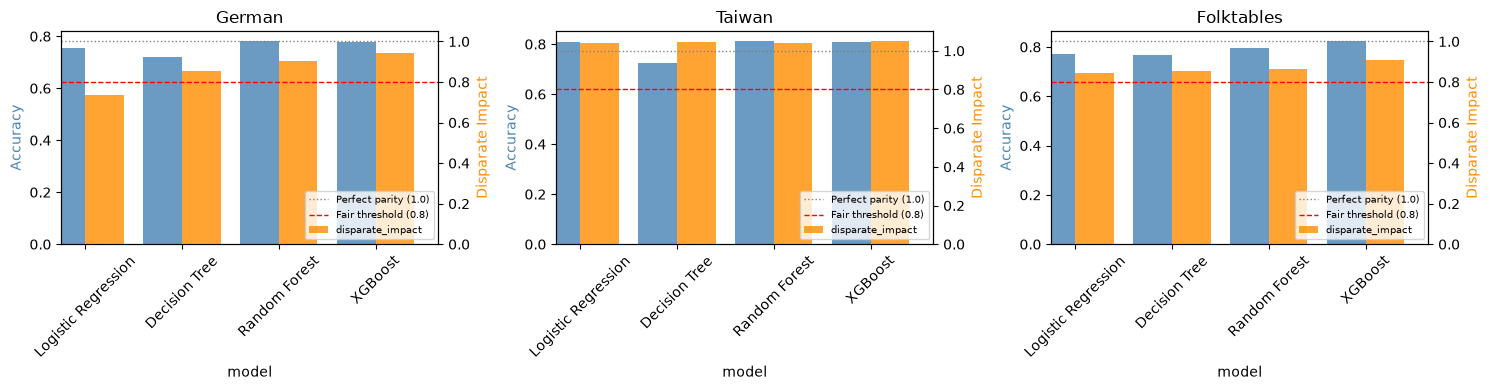

In [5]:
datasets = ['german', 'taiwan', 'folktables']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, ds in zip(axes, datasets):
    df = pd.read_csv(f'../results/baseline_{ds}.csv', index_col=0)
    ax2 = ax.twinx()
    df['accuracy'].plot(kind='bar', ax=ax, color='steelblue', width=0.4, position=1, alpha=0.8)
    df['disparate_impact'].plot(kind='bar', ax=ax2, color='darkorange', width=0.4, position=0, alpha=0.8)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax2.axhline(1.0, color='gray', linestyle=':', linewidth=1, label='Perfect parity (1.0)')
    ax2.axhline(0.8, color='red', linestyle='--', linewidth=1, label='Fair threshold (0.8)')
    ax2.legend(fontsize=7, loc='lower right')
    ax.set_title(ds.capitalize())
    ax.set_ylabel('Accuracy', color='steelblue')
    ax2.set_ylabel('Disparate Impact', color='darkorange')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../results/accuracy_vs_fairness.png')
plt.show()

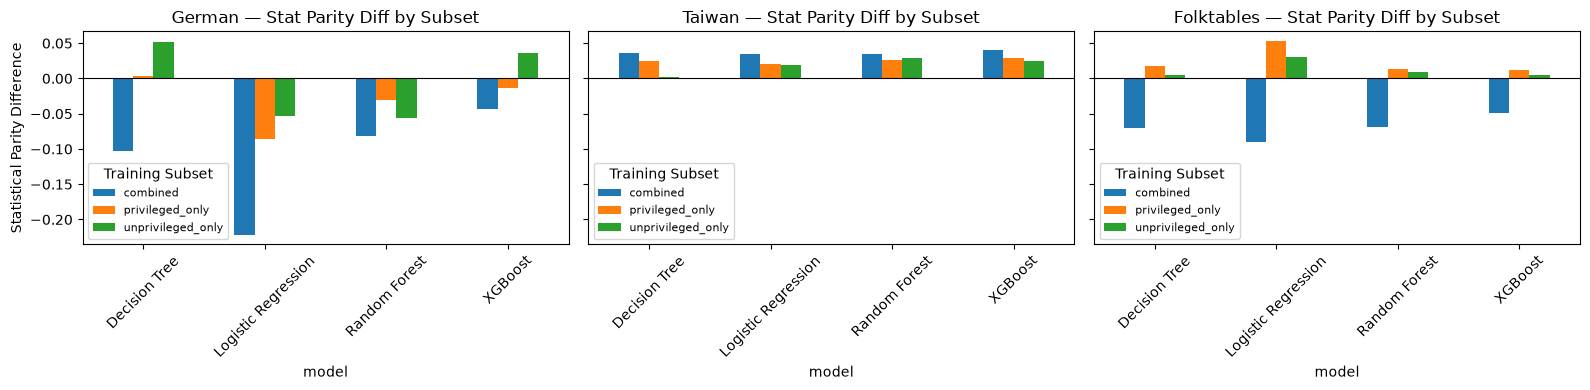

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, ds in zip(axes, datasets):
    df = pd.read_csv(f'../results/subset_{ds}.csv', index_col=[0, 1])
    pivot = df['stat_parity_diff'].unstack(level=0)
    pivot.plot(kind='bar', ax=ax)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'{ds.capitalize()} — Stat Parity Diff by Subset')
    ax.set_ylabel('Statistical Parity Difference')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Training Subset', fontsize=8)

plt.tight_layout()
plt.savefig('../results/subset_comparison.png')
plt.show()

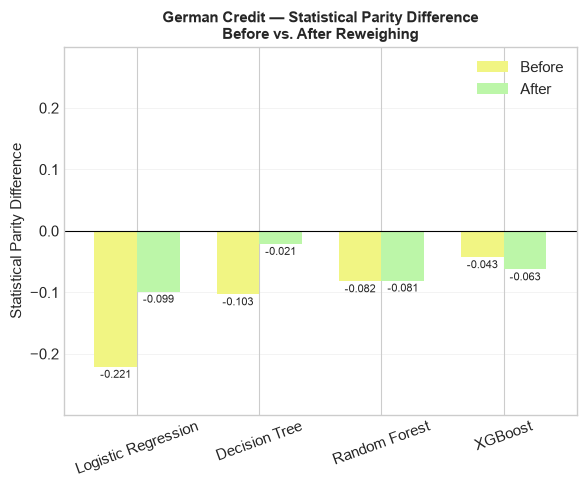

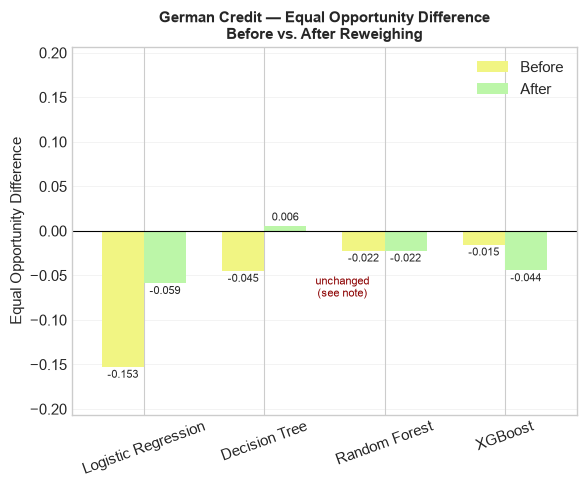

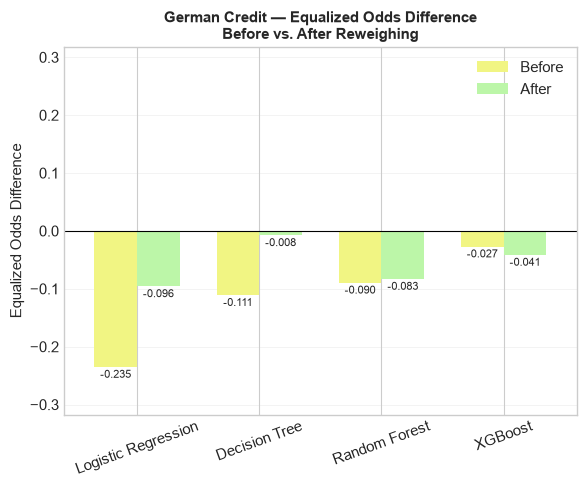

In [21]:
before = pd.read_csv('../results/baseline_german_for_comparison.csv', index_col=0)
after = pd.read_csv('../results/reweighing_german.csv', index_col=0)

metrics_to_plot = ['stat_parity_diff', 'equal_opp_diff', 'equalized_odds_diff']
metric_labels = {
    'stat_parity_diff': 'Statistical Parity Difference',
    'equal_opp_diff': 'Equal Opportunity Difference',
    'equalized_odds_diff': 'Equalized Odds Difference'
}

for metric in metrics_to_plot:
    comparison = pd.DataFrame({'Before': before[metric], 'After': after[metric]})

    fig, ax = plt.subplots(figsize=(6, 5))
    comparison.plot(kind='bar', ax=ax, color=["#F1F583", "#bcf6a8"], width=0.7)

    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'German Credit — {metric_labels[metric]}\nBefore vs. After Reweighing', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel(metric_labels[metric])
    ax.tick_params(axis='x', rotation=20)
    ax.grid(True, linewidth=0.4, alpha=0.4, axis='y')
    ax.legend(title=None, loc='upper right', frameon=False)

    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)

    ymax = max(abs(comparison.values.min()), abs(comparison.values.max())) * 1.35
    ax.set_ylim(-ymax, ymax)

    # flag the Random Forest coincidence only on the equal opportunity plot
    if metric == 'equal_opp_diff':
        rf_idx = list(comparison.index).index('Random Forest')
        ax.annotate('unchanged\n(see note)',
                     xy=(rf_idx, after.loc['Random Forest', metric]),
                     xytext=(rf_idx - 0.35, after.loc['Random Forest', metric] - ymax * 0.25),
                     fontsize=8, color='darkred', ha='center')

    plt.tight_layout()
    plt.savefig(f'../results/reweighing_{metric}.png', dpi=150, bbox_inches='tight')
    plt.show()

Separated accuracy vs fairness diagrams

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

datasets = ['german', 'taiwan', 'folktables']

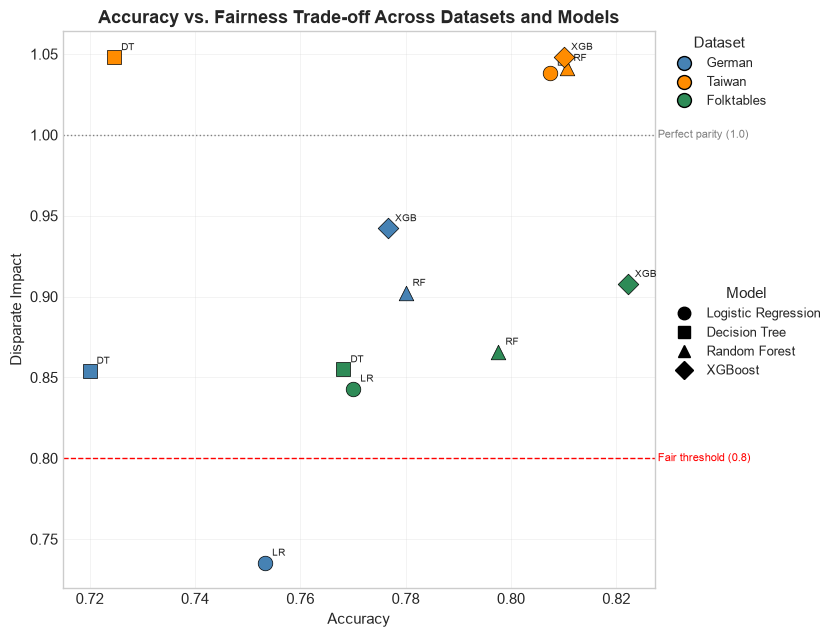

In [13]:
fig, ax = plt.subplots(figsize=(8.5, 6.5))

colors = {'german': 'steelblue', 'taiwan': 'darkorange', 'folktables': 'seagreen'}
markers = {'Logistic Regression': 'o', 'Decision Tree': 's', 'Random Forest': '^', 'XGBoost': 'D'}
model_abbrev = {'Logistic Regression': 'LR', 'Decision Tree': 'DT', 'Random Forest': 'RF', 'XGBoost': 'XGB'}

for ds in datasets:
    df = pd.read_csv(f'../results/baseline_{ds}.csv', index_col=0)
    for model_name, row in df.iterrows():
        ax.scatter(row['accuracy'], row['disparate_impact'],
                   color=colors[ds], marker=markers[model_name], s=110,
                   edgecolor='black', linewidth=0.5, zorder=3)
        ax.annotate(model_abbrev[model_name],
                    (row['accuracy'], row['disparate_impact']),
                    xytext=(5, 5), textcoords='offset points', fontsize=7.5)

ax.axhline(1.0, color='gray', linestyle=':', linewidth=1, zorder=1)
ax.axhline(0.8, color='red', linestyle='--', linewidth=1, zorder=1)
ax.text(1.005, 0.8, 'Fair threshold (0.8)', color='red', fontsize=8,
        va='center', transform=ax.get_yaxis_transform())
ax.text(1.005, 1.0, 'Perfect parity (1.0)', color='gray', fontsize=8,
        va='center', transform=ax.get_yaxis_transform())

# lighter, thinner gridlines so they don't visually compete with the data
ax.grid(True, linewidth=0.4, alpha=0.4)

ax.set_xlabel('Accuracy')
ax.set_ylabel('Disparate Impact')
ax.set_title('Accuracy vs. Fairness Trade-off Across Datasets and Models')

from matplotlib.lines import Line2D
color_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                         markeredgecolor='black', markersize=10, label=ds.capitalize())
                  for ds, c in colors.items()]
marker_handles = [Line2D([0], [0], marker=m, color='w', markerfacecolor='black',
                          markeredgecolor='black', markersize=9, linestyle='None', label=name)
                   for name, m in markers.items()]

# both legends moved fully outside the plot, stacked vertically on the right
legend1 = ax.legend(handles=color_handles, title='Dataset', loc='upper left',
                     bbox_to_anchor=(1.02, 1.0), fontsize=9, borderaxespad=0)
ax.add_artist(legend1)
ax.legend(handles=marker_handles, title='Model', loc='upper left',
          bbox_to_anchor=(1.02, 0.55), fontsize=9, borderaxespad=0)

plt.tight_layout()
plt.savefig('../results/accuracy_vs_fairness_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

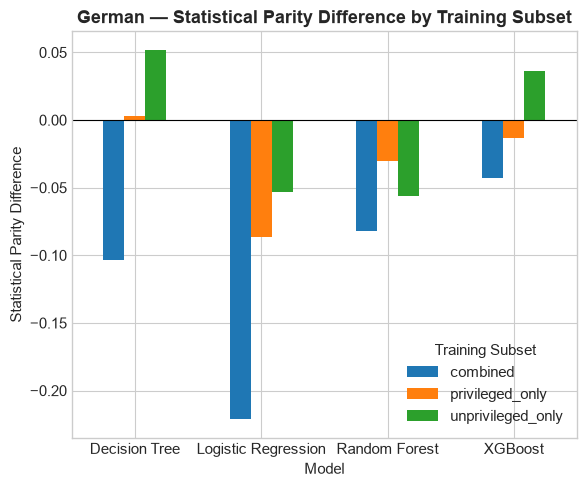

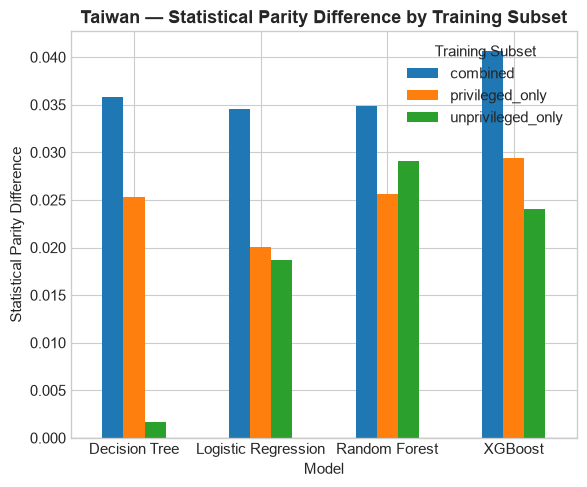

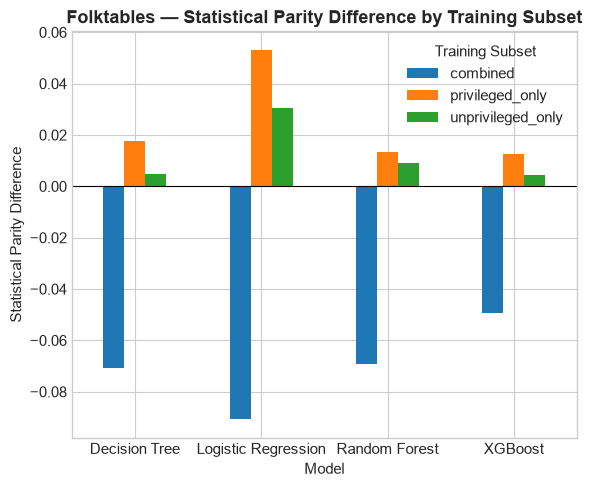

In [16]:
for ds in datasets:
    df = pd.read_csv(f'../results/subset_{ds}.csv', index_col=[0, 1])
    pivot = df['stat_parity_diff'].unstack(level=0)

    fig, ax = plt.subplots(figsize=(6,5))
    pivot.plot(kind='bar', ax=ax)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'{ds.capitalize()} — Statistical Parity Difference by Training Subset')
    ax.set_ylabel('Statistical Parity Difference')
    ax.set_xlabel('Model')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title='Training Subset')

    plt.tight_layout()
    plt.savefig(f'../results/subset_comparison_{ds}.png', dpi=150)
    plt.show()

Heatmap

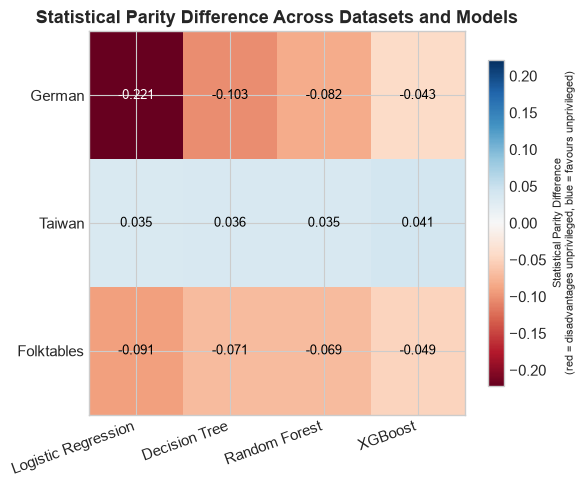

In [22]:

# assemble a dataset x model matrix of stat_parity_diff values
spd_matrix = pd.DataFrame(index=[ds.capitalize() for ds in datasets],
                           columns=['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost'],
                           dtype=float)

for ds in datasets:
    df = pd.read_csv(f'../results/baseline_{ds}.csv', index_col=0)
    spd_matrix.loc[ds.capitalize()] = df['stat_parity_diff']

fig, ax = plt.subplots(figsize=(6, 5))

# diverging colormap centered at 0: red = disadvantages unprivileged group,
# blue = favours unprivileged group, white = parity
vmax = spd_matrix.abs().values.max()
im = ax.imshow(spd_matrix.values.astype(float), cmap='RdBu', vmin=-vmax, vmax=vmax, aspect='auto')

ax.set_xticks(range(len(spd_matrix.columns)))
ax.set_xticklabels(spd_matrix.columns, rotation=20, ha='right')
ax.set_yticks(range(len(spd_matrix.index)))
ax.set_yticklabels(spd_matrix.index)

# annotate each cell with its actual value
for i in range(spd_matrix.shape[0]):
    for j in range(spd_matrix.shape[1]):
        val = spd_matrix.values[i, j]
        text_color = 'white' if abs(val) > vmax * 0.6 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center', color=text_color, fontsize=9)

cbar = fig.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label('Statistical Parity Difference\n(red = disadvantages unprivileged, blue = favours unprivileged)', fontsize=8)

ax.set_title('Statistical Parity Difference Across Datasets and Models')
plt.tight_layout()
plt.savefig('../results/spd_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()